<h1> Data Pre-Processing

<h3>Loading the dataset

Importing necessary libraries to load the dataset

In [34]:
import pandas as pd
import numpy as np

Load the dataset using pandas

In [35]:
import warnings
warnings.filterwarnings('ignore')

df_freq = pd.read_csv('freMTPL2freq.csv')
df_sev = pd.read_csv('freMTPL2sev.csv')

In [36]:
df_freq

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine
...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne


In [37]:
df_sev

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00
...,...,...
26634,3254353,1200.00
26635,3254353,1800.00
26636,3254353,1000.00
26637,2222064,767.55


<h3>Checking for the missing values in both the dataset

In [38]:
#checking missing values in the 'freMTPL2freq' dataset
missing_freq = df_freq.isnull().sum()

#checking missing values in the 'freMTPL2sev' dataset
missing_sev = df_sev.isnull().sum()

#print the count of missing values for each column
print("Missing values in the 'freMTPL2freq' dataset:")
print(missing_freq)

print("\nMissing Values in 'freMTPL2sev' dataset:")
print(missing_sev)

Missing values in the 'freMTPL2freq' dataset:
IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64

Missing Values in 'freMTPL2sev' dataset:
IDpol          0
ClaimAmount    0
dtype: int64


<h3>Merging 'df_freq' and 'df_sev' into a single dataframe

In [39]:
#Aggregate the claim amounts by policyID(IDpol) before merging df_freq with df_sev
df_sev_grp = df_sev.groupby(['IDpol'])[['ClaimAmount']].agg('sum').reset_index()

#Create an outer merge between df_freq and df_sev, based on 'IDpol' then set the index again to 'IDpol'
merged_df = pd.merge(df_freq, df_sev_grp, how = 'outer', on = 'IDpol').fillna(0).set_index('IDpol')

#check whether the total amoount of claims paid in the merged_df and df_sev are equal
Claim_Sum_orignal = round(sum(df_sev['ClaimAmount'], 2))
print("Sum of the ClaimAmount in orignal data =" , Claim_Sum_orignal)
Claim_Sum_merged = round(sum(merged_df['ClaimAmount'], 2))
print("Sum of ClaimAMount in merged data =", Claim_Sum_merged)
print('\n')
if Claim_Sum_orignal == Claim_Sum_merged:
    print("Dataframes successfully Merged")
else:
    print("Merge unsuccessful")

Sum of the ClaimAmount in orignal data = 60697933
Sum of ClaimAMount in merged data = 60697933


Dataframes successfully Merged


Reviewing the columns and their datatypes of 'merged_df' 

In [40]:
print(merged_df.columns)

print(merged_df.dtypes)

Index(['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus',
       'VehBrand', 'VehGas', 'Area', 'Density', 'Region', 'ClaimAmount'],
      dtype='object')
ClaimNb        float64
Exposure       float64
VehPower       float64
VehAge         float64
DrivAge        float64
BonusMalus     float64
VehBrand        object
VehGas          object
Area            object
Density        float64
Region          object
ClaimAmount    float64
dtype: object


In [2]:
merged_df

NameError: name 'merged_df' is not defined

Printing first 10 rows of the merged_df dataframe

In [41]:
print(merged_df.head(10))

       ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
IDpol                                                                      
1.0        1.0      0.10       5.0     0.0     55.0        50.0      B12   
3.0        1.0      0.77       5.0     0.0     55.0        50.0      B12   
5.0        1.0      0.75       6.0     2.0     52.0        50.0      B12   
10.0       1.0      0.09       7.0     0.0     46.0        50.0      B12   
11.0       1.0      0.84       7.0     0.0     46.0        50.0      B12   
13.0       1.0      0.52       6.0     2.0     38.0        50.0      B12   
15.0       1.0      0.45       6.0     2.0     38.0        50.0      B12   
17.0       1.0      0.27       7.0     0.0     33.0        68.0      B12   
18.0       1.0      0.71       7.0     0.0     33.0        68.0      B12   
21.0       1.0      0.15       7.0     0.0     41.0        50.0      B12   

        VehGas Area  Density                Region  ClaimAmount  
IDpol                

Printing last 10 rows of the merged_df dataframe

In [42]:
print(merged_df.tail(10))

           ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
IDpol                                                                          
6114327.0      0.0   0.00274       4.0     0.0     41.0        95.0      B12   
6114328.0      0.0   0.00274       6.0     2.0     45.0        50.0      B12   
6114329.0      0.0   0.00274       4.0     0.0     60.0        50.0      B12   
6114330.0      0.0   0.00274       7.0     6.0     29.0        54.0      B12   
2220367.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   
2227533.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   
2262511.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   
2277846.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   
2282134.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   
2286775.0      0.0   0.00000       0.0     0.0      0.0         0.0        0   

            VehGas Area  Density       

<h3>Handling the mismatched rows 

In [43]:
'''It can be seen that a few rows in the 'merged_df' has values assinged
   as zero in all the columns except 'IDpol' and 'ClaimAmount' which means that
   those policy IDs(IDpol) does not exist in the 'df_freq' data.'''

#identifying mismatched policyIDs
missing_IDpols = set(df_sev['IDpol']) - set(df_freq['IDpol'])

#filter out the rows with mismatched policyIDs from the df_sev dataframe
missing_rows = df_sev[df_sev['IDpol'].isin(missing_IDpols)]

#calculate the sum of ClaimAmount for the mismatched rows
sum_ClaimAmount_missing = missing_rows['ClaimAmount'].sum()

#print the mismatched policyIDs and calculate the percentage of ClaimAmount of policies that went missing from the orignal data
print('Policy IDs that are missing in the orignal dataset(df_freq) are:', missing_IDpols)
print('\n')
print('Sum of the Claim Amount for Missing Policies:', sum_ClaimAmount_missing)
print('\n')
percentage = (sum_ClaimAmount_missing / Claim_Sum_orignal) * 100

print("The percentage of the sum of ClaimAmount of policies that are missing in the orignal df_freq data is:", percentage, '%')



Policy IDs that are missing in the orignal dataset(df_freq) are: {2227533, 2220367, 2262511, 2282134, 2286775, 2277846}


Sum of the Claim Amount for Missing Policies: 788714.1800000002


The percentage of the sum of ClaimAmount of policies that are missing in the orignal df_freq data is: 1.2994086306036157 %


Since the Claim values of the policyIDs(IDpol) that are not present in the orignal data(df_freq) is just around 1% of the total claim amount, those entries can be deleted and the project can be moved to further analysis.

In [44]:
#identify the rows to be dropped
rows_to_drop = merged_df.index[merged_df.index.isin(missing_IDpols)]

#drop the rows from the merged_df
merged_df_cleaned = merged_df.drop(rows_to_drop)

merged_df_cleaned

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount
IDpol,,,,,,,,,,,,
1.0,1.0,0.10000,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0
3.0,1.0,0.77000,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0
5.0,1.0,0.75000,6.0,2.0,52.0,50.0,B12,Diesel,B,54.0,Picardie,0.0
10.0,1.0,0.09000,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0
11.0,1.0,0.84000,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6114326.0,0.0,0.00274,4.0,0.0,54.0,50.0,B12,Regular,E,3317.0,Provence-Alpes-Cotes-D'Azur,0.0
6114327.0,0.0,0.00274,4.0,0.0,41.0,95.0,B12,Regular,E,9850.0,Ile-de-France,0.0
6114328.0,0.0,0.00274,6.0,2.0,45.0,50.0,B12,Diesel,D,1323.0,Rhone-Alpes,0.0


<h3>Creating a new column that specifies age catgories

In [45]:
#define bins and labels for age
age_bins = [18, 34, 59, float('inf')]
age_labels = ['Young Adults', 'Middle-Aged Adults', 'Senior']

#create a new column 'AgeCategory' with age categories
merged_df_cleaned['AgeCategory'] = pd.cut(merged_df_cleaned['DrivAge'], bins = age_bins, labels = age_labels)

print(merged_df_cleaned[['DrivAge', 'AgeCategory']])

           DrivAge         AgeCategory
IDpol                                 
1.0           55.0  Middle-Aged Adults
3.0           55.0  Middle-Aged Adults
5.0           52.0  Middle-Aged Adults
10.0          46.0  Middle-Aged Adults
11.0          46.0  Middle-Aged Adults
...            ...                 ...
6114326.0     54.0  Middle-Aged Adults
6114327.0     41.0  Middle-Aged Adults
6114328.0     45.0  Middle-Aged Adults
6114329.0     60.0              Senior
6114330.0     29.0        Young Adults

[678013 rows x 2 columns]


<h3>Creating a new column that specifies Bonus/Malus catgories

In [46]:
#define bins and labels for Bonus/Malus
bonus_bins = [0, 50, 100, 200, 300, float('inf')]
bonus_labels = ['Excellent', 'Good', 'Average', 'Poor', 'Very Poor']

#create a column 'BonusMalusCategory' with Bonus/Malus categories
merged_df_cleaned['BonusMalusCategory'] = pd.cut(merged_df_cleaned['BonusMalus'], bins=bonus_bins, labels=bonus_labels)

print(merged_df_cleaned[['BonusMalus', 'BonusMalusCategory']])

           BonusMalus BonusMalusCategory
IDpol                                   
1.0              50.0          Excellent
3.0              50.0          Excellent
5.0              50.0          Excellent
10.0             50.0          Excellent
11.0             50.0          Excellent
...               ...                ...
6114326.0        50.0          Excellent
6114327.0        95.0               Good
6114328.0        50.0          Excellent
6114329.0        50.0          Excellent
6114330.0        54.0               Good

[678013 rows x 2 columns]


<h1>Exploratory Data Analysis

Importing necassary libraries to generate plots

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

<h3>Descriptive Statistics

In [48]:
#Summary of the statistics
statistical_summary = merged_df_cleaned.describe()
print(statistical_summary)

             ClaimNb       Exposure       VehPower         VehAge  \
count  678013.000000  678013.000000  678013.000000  678013.000000   
mean        0.053247       0.528750       6.454631       7.044265   
std         0.240117       0.364442       2.050906       5.666232   
min         0.000000       0.002732       4.000000       0.000000   
25%         0.000000       0.180000       5.000000       2.000000   
50%         0.000000       0.490000       6.000000       6.000000   
75%         0.000000       0.990000       7.000000      11.000000   
max        16.000000       2.010000      15.000000     100.000000   

             DrivAge     BonusMalus        Density   ClaimAmount  
count  678013.000000  678013.000000  678013.000000  6.780130e+05  
mean       45.499122      59.761502    1792.422405  8.835998e+01  
std        14.137444      15.636658    3958.646564  5.822454e+03  
min        18.000000      50.000000       1.000000  0.000000e+00  
25%        34.000000      50.000000      92

In [49]:
#Display the first few rows of the Dataframe
merged_df_cleaned.head()


,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,AgeCategory,BonusMalusCategory
IDpol,,,,,,,,,,,,,,
1.0,1.0,0.10,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0,Middle-Aged Adults,Excellent
3.0,1.0,0.77,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0,Middle-Aged Adults,Excellent
5.0,1.0,0.75,6.0,2.0,52.0,50.0,B12,Diesel,B,54.0,Picardie,0.0,Middle-Aged Adults,Excellent
10.0,1.0,0.09,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0,Middle-Aged Adults,Excellent
11.0,1.0,0.84,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0,Middle-Aged Adults,Excellent


In [50]:
#Display the correlation 
correlation_matrix = merged_df_cleaned.corr() 
print(correlation_matrix)

              ClaimNb  Exposure  VehPower    VehAge   DrivAge  BonusMalus  \
ClaimNb      1.000000  0.068909 -0.004259 -0.021768  0.011392    0.050544   
Exposure     0.068909  1.000000 -0.045259  0.151554  0.171873   -0.183018   
VehPower    -0.004259 -0.045259  1.000000 -0.006001  0.030108   -0.075895   
VehAge      -0.021768  0.151554 -0.006001  1.000000 -0.059213    0.079923   
DrivAge      0.011392  0.171873  0.030108 -0.059213  1.000000   -0.479966   
BonusMalus   0.050544 -0.183018 -0.075895  0.079923 -0.479966    1.000000   
Density      0.010754 -0.071085  0.042901 -0.090428 -0.004700    0.077717   
ClaimAmount  0.071185  0.002244  0.001275  0.002321 -0.003663    0.009956   

              Density  ClaimAmount  
ClaimNb      0.010754     0.071185  
Exposure    -0.071085     0.002244  
VehPower     0.042901     0.001275  
VehAge      -0.090428     0.002321  
DrivAge     -0.004700    -0.003663  
BonusMalus   0.077717     0.009956  
Density      1.000000    -0.000056  
ClaimAmoun

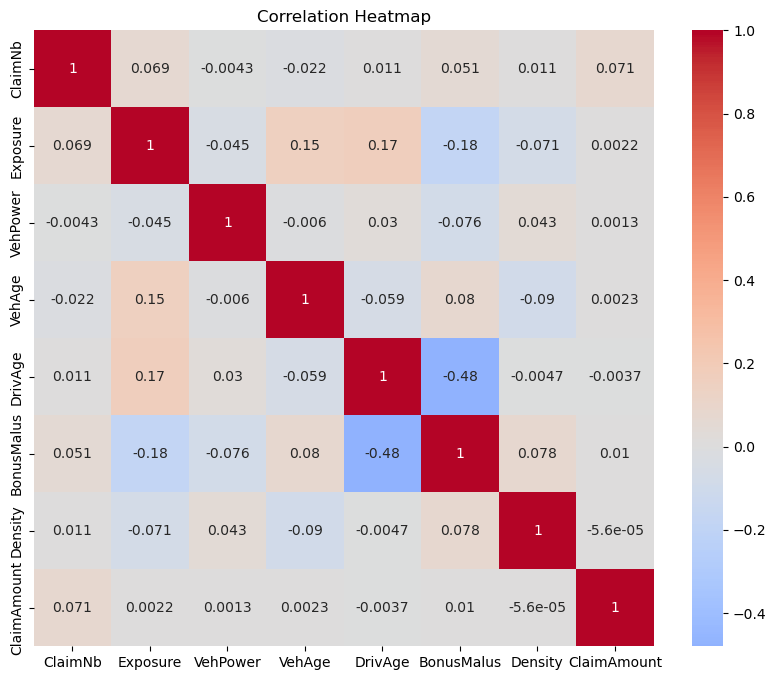

In [51]:
#Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

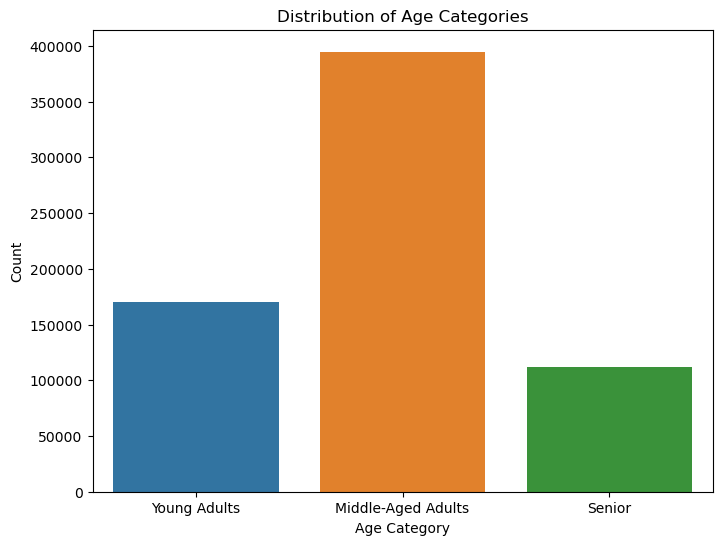

In [52]:
# Create a bar plot 
plt.figure(figsize=(8, 6))
sns.countplot(data=merged_df_cleaned, x='AgeCategory', order=['Young Adults', 'Middle-Aged Adults', 'Senior'])
plt.title('Distribution of Age Categories')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.show()

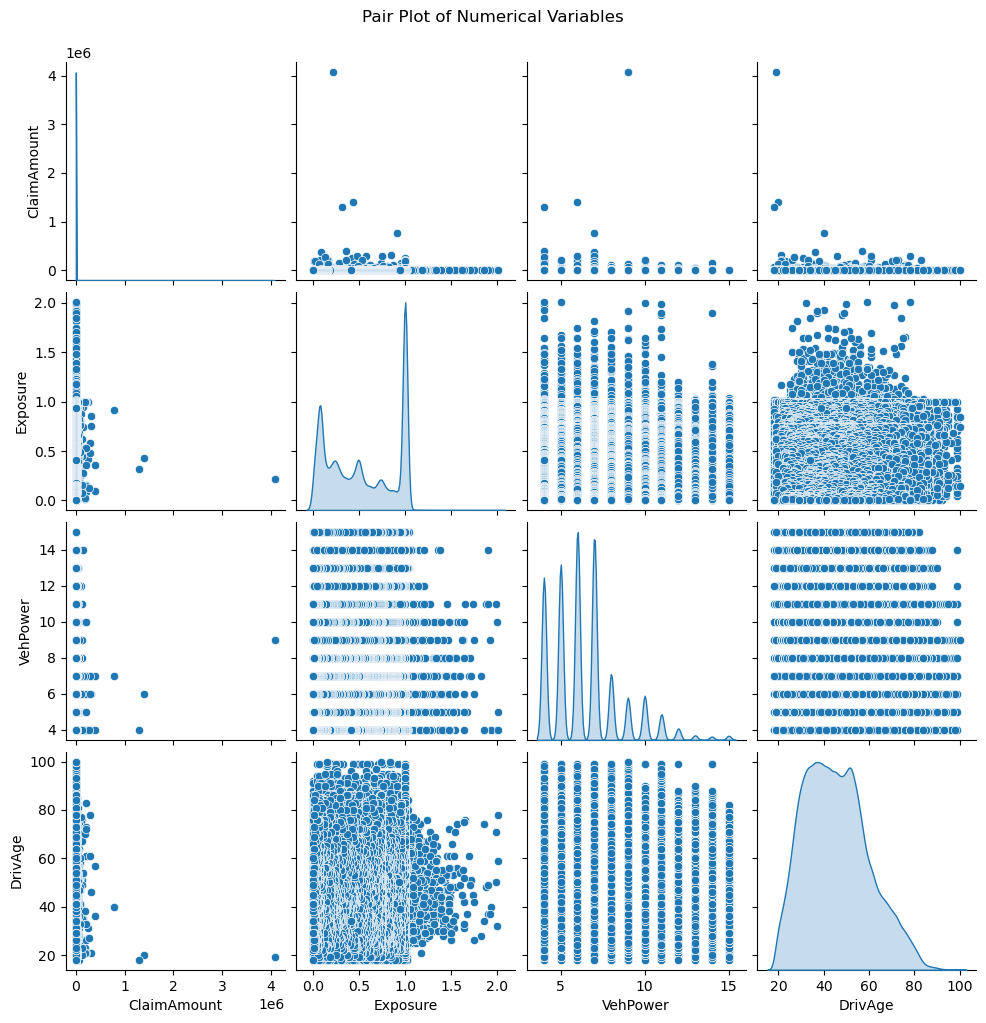

In [20]:
# Create a pair plot 
sns.pairplot(data=merged_df_cleaned[['ClaimAmount', 'Exposure', 'VehPower', 'DrivAge']], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

In [53]:
#create a new variable called 'Freq'
merged_df_cleaned['Freq'] = merged_df_cleaned['ClaimNb']/merged_df_cleaned['Exposure']

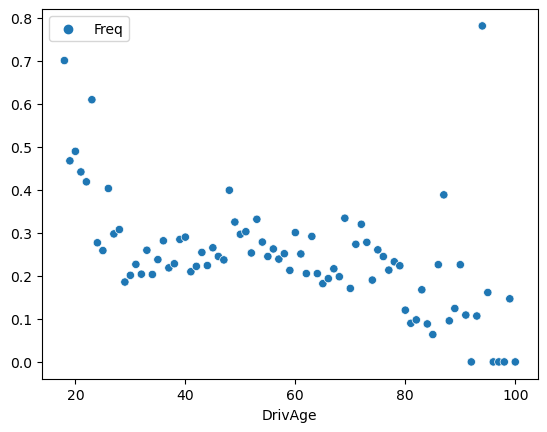

In [54]:
Freq = merged_df_cleaned.groupby('DrivAge',as_index=False).agg({'Freq': 'mean'})
sns.scatterplot(data=pd.pivot_table(index='DrivAge', values='Freq', data=merged_df_cleaned))
plt.show()

In [26]:
#Converting the aggregated 'Freq' column to its orignal form
merged_df_cleaned['Freq'] = merged_df_cleaned['ClaimNb'] / merged_df_cleaned['Exposure']

In [30]:
#Save the cleaned dataframe for Visualisation
file_path = r'C:\Users\K2175303\Downloads\merged_df_cleaned.csv'
merged_df_cleaned.to_csv(file_path, index = True)

<h3>Model Building and Evaluation

In [55]:
merged_df_cleaned

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,AgeCategory,BonusMalusCategory,Freq
IDpol,,,,,,,,,,,,,,,
1.0,1.0,0.10000,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0,Middle-Aged Adults,Excellent,10.000000
3.0,1.0,0.77000,5.0,0.0,55.0,50.0,B12,Regular,D,1217.0,Rhone-Alpes,0.0,Middle-Aged Adults,Excellent,1.298701
5.0,1.0,0.75000,6.0,2.0,52.0,50.0,B12,Diesel,B,54.0,Picardie,0.0,Middle-Aged Adults,Excellent,1.333333
10.0,1.0,0.09000,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0,Middle-Aged Adults,Excellent,11.111111
11.0,1.0,0.84000,7.0,0.0,46.0,50.0,B12,Diesel,B,76.0,Aquitaine,0.0,Middle-Aged Adults,Excellent,1.190476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6114326.0,0.0,0.00274,4.0,0.0,54.0,50.0,B12,Regular,E,3317.0,Provence-Alpes-Cotes-D'Azur,0.0,Middle-Aged Adults,Excellent,0.000000
6114327.0,0.0,0.00274,4.0,0.0,41.0,95.0,B12,Regular,E,9850.0,Ile-de-France,0.0,Middle-Aged Adults,Good,0.000000
6114328.0,0.0,0.00274,6.0,2.0,45.0,50.0,B12,Diesel,D,1323.0,Rhone-Alpes,0.0,Middle-Aged Adults,Excellent,0.000000


Data Pre-Processing

In [56]:
from sklearn.preprocessing import LabelEncoder

#encode categorical variables into numerical
encoder = LabelEncoder()
categorical_columns = ['VehBrand', 'VehGas', 'Area', 'Region']
for column in categorical_columns:
    merged_df_cleaned[column] = encoder.fit_transform(merged_df_cleaned[column])

#create a column with Binary values of Claims made or not using the column 'ClaimAmount'
merged_df_cleaned['ClaimMade'] = merged_df_cleaned['ClaimAmount'].apply(lambda x:1 if x > 0 else 0)

print("DataFrame after Pre-Processing:")
print(merged_df_cleaned.head())

DataFrame after Pre-Processing:
       ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus  VehBrand  \
IDpol                                                                       
1.0        1.0      0.10       5.0     0.0     55.0        50.0         3   
3.0        1.0      0.77       5.0     0.0     55.0        50.0         3   
5.0        1.0      0.75       6.0     2.0     52.0        50.0         3   
10.0       1.0      0.09       7.0     0.0     46.0        50.0         3   
11.0       1.0      0.84       7.0     0.0     46.0        50.0         3   

       VehGas  Area  Density  Region  ClaimAmount         AgeCategory  \
IDpol                                                                   
1.0         1     3   1217.0      20          0.0  Middle-Aged Adults   
3.0         1     3   1217.0      20          0.0  Middle-Aged Adults   
5.0         0     1     54.0      17          0.0  Middle-Aged Adults   
10.0        0     1     76.0       1          0.0  Middle-Aged 

In [57]:
#split the dataset into test and train
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

#Features and target variables
X = merged_df_cleaned[['Freq', 'VehPower', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Region']]
y = merged_df_cleaned['ClaimMade']

# Splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
X_train

,Freq,VehPower,DrivAge,BonusMalus,VehBrand,VehGas,Area,Region
IDpol,,,,,,,,
3099378.0,1.0,6.0,59.0,50.0,6,0,1,1
3068220.0,0.0,10.0,61.0,50.0,7,1,2,12
2107013.0,0.0,7.0,42.0,50.0,0,0,0,1
2121304.0,0.0,6.0,52.0,50.0,6,0,0,20
6084903.0,0.0,5.0,71.0,50.0,3,1,3,5
...,...,...,...,...,...,...,...,...
2118590.0,0.0,10.0,57.0,85.0,3,0,3,20
3020007.0,0.0,10.0,46.0,56.0,9,0,3,11
1089081.0,0.0,8.0,35.0,50.0,9,1,4,19


In [59]:
y_train

IDpol
3099378.0    1
3068220.0    0
2107013.0    0
2121304.0    0
6084903.0    0
            ..
2118590.0    0
3020007.0    0
1089081.0    0
6104970.0    0
1068138.0    0
Name: ClaimMade, Length: 542410, dtype: int64

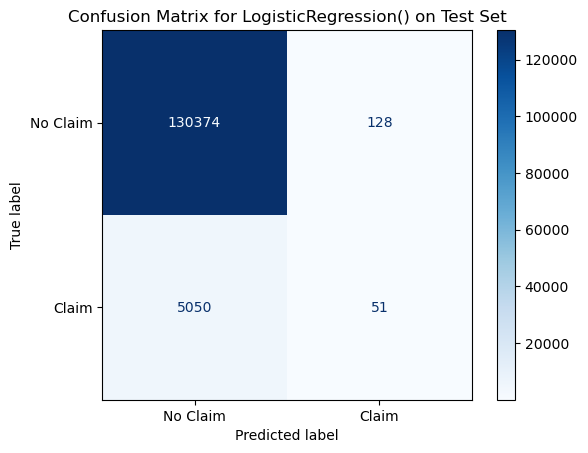

LOGISTIC REGRESSION:
Model performance of training set
Accuracy: 0.9629
F1 score: 0.0206
Precision: 0.3103
Recall: 0.0106
ROC AUC Score: 0.5049
-----------------------------------
Model performance of test set
Accuracy: 0.9618
F1 score: 0.0193
Precision: 0.2849
Recall: 0.0100
ROC AUC Score: 0.5045
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx




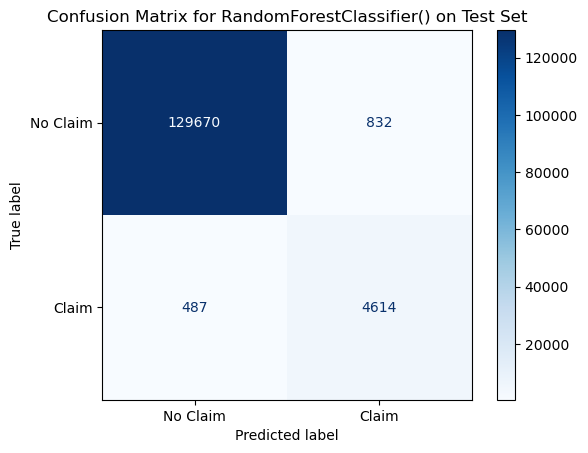

RANDOM FOREST:
Model performance of training set
Accuracy: 0.9996
F1 score: 0.9941
Precision: 0.9945
Recall: 0.9938
ROC AUC Score: 0.9968
-----------------------------------
Model performance of test set
Accuracy: 0.9903
F1 score: 0.8749
Precision: 0.8472
Recall: 0.9045
ROC AUC Score: 0.9491
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx




In [60]:
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,roc_curve, confusion_matrix

#ignore all warnings
warnings.filterwarnings('ignore')
models = {
    "LOGISTIC REGRESSION:": LogisticRegression(),
    "RANDOM FOREST:": RandomForestClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    #Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) #accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) #f1_score
    model_train_precision = precision_score(y_train, y_train_pred) #precision
    model_train_recall = recall_score(y_train, y_train_pred) #recall
    model_train_rocauc = roc_auc_score(y_train, y_train_pred) #roc_score
    
    #Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) #accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) #f1_score
    model_test_precision = precision_score(y_test, y_test_pred) #precision
    model_test_recall = recall_score(y_test, y_test_pred) #recall
    model_test_rocauc = roc_auc_score(y_test, y_test_pred) #roc_score
    
    confmat = confusion_matrix(y_test, y_test_pred)
    
    #Plot confusion matrix for test set
    disp = ConfusionMatrixDisplay(confusion_matrix=confmat, display_labels=['No Claim', 'Claim'])
    
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model} on Test Set')
    plt.show()
    
    print(list(models.keys())[i])
    
    print("Model performance of training set")
    print("Accuracy: {:.4f}".format(model_train_accuracy))
    print("F1 score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC Score: {:.4f}".format(model_train_rocauc))
    
    print("-"*35)
    
    print("Model performance of test set")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC Score: {:.4f}".format(model_test_rocauc))
    
    print("x"*35)
    print('\n')

<h3>Tuning hyperparameters to improve the effeciency of the models

In [37]:
#hyperparameter training
logreg_params = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

randomf_params = {
    'n_estimators': [int(x) for x in np.linspace(50, 200, 8)],
    'max_depth': [int(x) for x in np.linspace(10, 110, 11)],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

randomsearch_models = [
    ("Logistic Regression", LogisticRegression(), logreg_params),
    ("Random Forest", RandomForestClassifier(), randomf_params)
]

randomsearch_models


[('Logistic Regression',
  LogisticRegression(),
  {'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
          4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
          2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
          1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
          5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
   'penalty': ['l1', 'l2'],
   'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}),
 ('Random Forest',
  RandomForestClassifier(),
  {'n_estimators': [50, 71, 92, 114, 135, 157, 178, 200],
   'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4]})]

In [38]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}
for name, model, params in randomsearch_models:
    random = RandomizedSearchCV(estimator = model,
                               param_distributions = params,
                               n_iter = 50,
                               cv = 3,
                               verbose = 2,
                               n_jobs = -1)
    random.fit(X_train, y_train)
    model_params[name] = random.best_params_
    
for model_name in model_params:
    print(f"Best Parameters for {model_name}:")
    print(model_params[model_name])
    

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters for Logistic Regression:
{'solver': 'saga', 'penalty': 'l1', 'C': 0.0001}
Best Parameters for Random Forest:
{'n_estimators': 178, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 110}


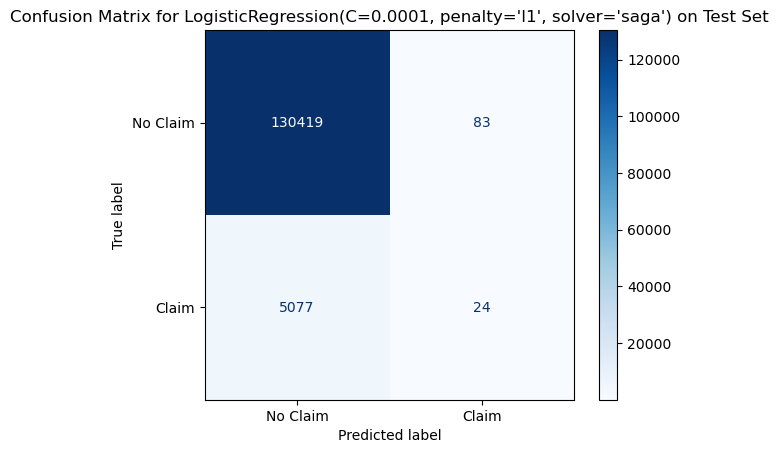

LogReg_BestModel:
Model performance of training set
Accuracy: 0.9632
F1 score: 0.0122
Precision: 0.3445
Recall: 0.0062
ROC AUC Score: 0.5029
-----------------------------------
Model performance of test set
Accuracy: 0.9619
F1 score: 0.0092
Precision: 0.2243
Recall: 0.0047
ROC AUC Score: 0.5020
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx




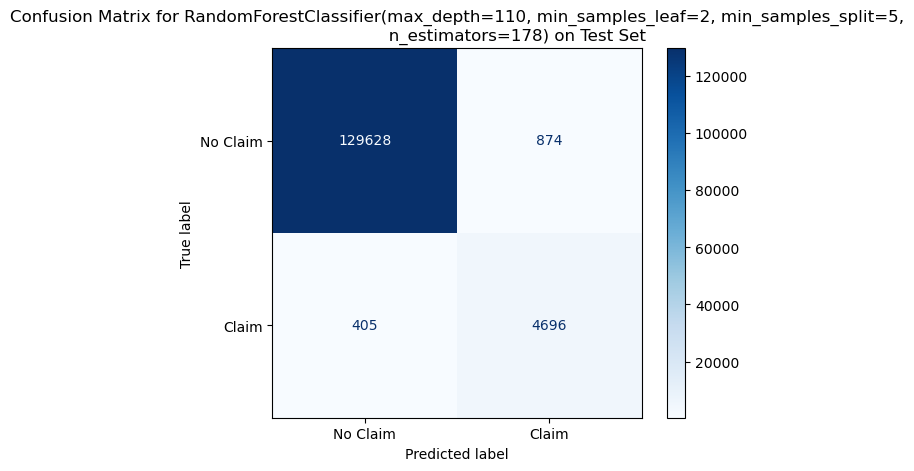

RandomF_BestModel:
Model performance of training set
Accuracy: 0.9963
F1 score: 0.9510
Precision: 0.9247
Recall: 0.9788
ROC AUC Score: 0.9879
-----------------------------------
Model performance of test set
Accuracy: 0.9906
F1 score: 0.8801
Precision: 0.8431
Recall: 0.9206
ROC AUC Score: 0.9570
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx




In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,roc_curve

best_models = {
    "LogReg_BestModel:": LogisticRegression(solver = 'saga', penalty = 'l1', C = 0.0001),
    "RandomF_BestModel:": RandomForestClassifier(n_estimators = 178, min_samples_split = 5, min_samples_leaf = 2, max_depth = 110)
}
for i in range(len(list(best_models))):
    model = list(best_models.values())[i]
    model.fit(X_train, y_train)
    
    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    #Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) #accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) #f1_score
    model_train_precision = precision_score(y_train, y_train_pred) #precision
    model_train_recall = recall_score(y_train, y_train_pred) #recall
    model_train_rocauc = roc_auc_score(y_train, y_train_pred) #roc_score
    
    #Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) #accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) #f1_score
    model_test_precision = precision_score(y_test, y_test_pred) #precision
    model_test_recall = recall_score(y_test, y_test_pred) #recall
    model_test_rocauc = roc_auc_score(y_test, y_test_pred) #roc_score
    
    confmat = confusion_matrix(y_test, y_test_pred)
    
    #Plot confusion matrix for test set
    disp = ConfusionMatrixDisplay(confusion_matrix=confmat, display_labels=['No Claim', 'Claim'])
    
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model} on Test Set')
    plt.show()
    
    print(list(best_models.keys())[i])
    
    print("Model performance of training set")
    print("Accuracy: {:.4f}".format(model_train_accuracy))
    print("F1 score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC Score: {:.4f}".format(model_train_rocauc))
    
    print("-"*35)
    
    print("Model performance of test set")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC Score: {:.4f}".format(model_test_rocauc))
    
    print("x"*35)
    print('\n')    

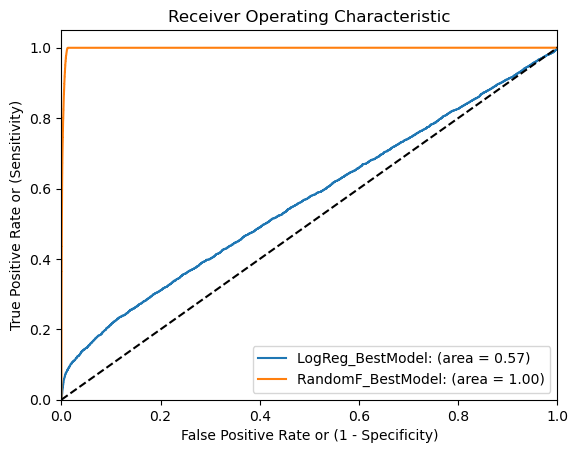

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

# Loop through each model to plot ROC curve
for i in range(len(list(best_models))):
    model = list(best_models.values())[i]
    
    y_pred_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    
    # Compute AUC
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{list(best_models.keys())[i]} (area = {roc_auc:.2f})')

# Add random prediction curve
plt.plot([0, 1], [0, 1], 'k--') 

# Add labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate or (1 - Specificity)')
plt.ylabel('True Positive Rate or (Sensitivity)')
plt.title('Receiver Operating Characteristic')

# Add legend
plt.legend(loc="lower right")
plt.show()


<h3>Using Recursive Elimination Function(RFE) to identify the number of features that are insignificant

In [34]:
from sklearn.feature_selection import RFE
 
model_rfe = RandomForestClassifier()

# Initialize RFE to perform feature selection
rfe = RFE(model_rfe, n_features_to_select=1) 

rfe.fit(X_train, y_train)

# Retrieve the feature rankings
feature_rankings = rfe.ranking_

# Print the feature rankings
print("Feature Rankings of the Random Forest Classifier Model:")
print(feature_rankings)

Feature Rankings of the Random Forest Classifier Model:
[1 6 2 5 4 8 7 3]


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE

# Initialize a RandomForestClassifier
model = RandomForestClassifier(n_estimators=178, min_samples_split=5, min_samples_leaf=2, max_depth=110)

# Initialize an empty list to store accuracy values
accuracy_values = []

# Initialize the number of features to start with
num_features = X_train.shape[1]

# Perform iterations to reduce features one at a time
while num_features >= 1:
    # Initialize RFE with the model and the current number of features
    rfe = RFE(model, n_features_to_select=num_features)
    
    rfe.fit(X_train, y_train)
    
    # Reduce the feature set to selected features
    X_train_rfe = X_train.loc[:, rfe.support_]
    X_test_rfe = X_test.loc[:, rfe.support_]
    
    model.fit(X_train_rfe, y_train)
    
    # Make predictions
    y_test_pred = model.predict(X_test_rfe)
    
    # Calculate accuracy and append to the accuracy_values list
    accuracy = accuracy_score(y_test, y_test_pred)
    accuracy_values.append(accuracy)
    
    # Reduce the number of features for the next iteration
    num_features -= 1

accuracy_values.reverse()

# Print the accuracy values
print("Accuracy Values for Different Feature Counts:", accuracy_values)


Accuracy Values for Different Feature Counts: [0.9884884552701636, 0.9874855276063214, 0.9892406510180454, 0.9894692595296565, 0.9898969786804127, 0.9902288297456546, 0.9902435786818876, 0.9907155446413427]


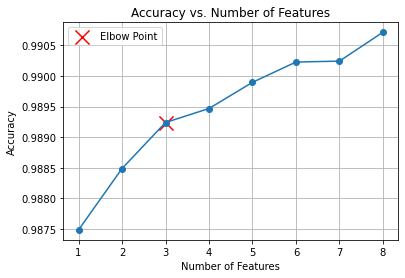

Elbow Point Feature Count: 3


In [48]:
import matplotlib.pyplot as plt
import numpy as np

sorted_avs = sorted(accuracy_values)
feature_counts = range(1, len(sorted_avs) + 1)

# Calculate the first differences
first_differences = np.diff(sorted_avs)

# Calculate the second differences
second_differences = np.diff(first_differences)

# Find the index where the second difference is significantly smaller
threshold = np.max(second_differences) * 0.1  
elbow_index = np.where(second_differences < threshold)[0][0] + 3  

# Create a line chart
feature_counts = range(1, len(sorted_avs) + 1)
plt.plot(feature_counts, sorted_avs, marker='o', linestyle='-')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features')
plt.grid(True)

# Mark the elbow point
plt.scatter(elbow_index, sorted_avs[elbow_index-1], c='red', marker='x', s = 200, label='Elbow Point')
plt.legend()

plt.show()

# Print the feature count at the elbow point
print("Elbow Point Feature Count:", elbow_index)